# Score Divergence 🔀

This notebook serves to visualize the divergence between similiar and different scences.

## Experiment 1: Indoor: Same vs. Different

In this experiment, we will compare the divergence between one indoor scene vs another. These were taken of different rooms and vary in object movement and lighting.

We should ignore pairwise, as we are comparing the divergence between the two similar / difference scenes. A pairwise comparison would always have large divergence as it compares each frame to every other frame.

In [1]:
from utils.csvs import TrainSimilarityScores

In [2]:
path = '2_fov/1_office/flex_train_similarity_scores'
office = TrainSimilarityScores(f'{path}/*.csv')#, f'{path}/pairwise*.csv')
office.summary_table()

Metric [Scene] | Average | Minimum | Maximum | St. Dev. | St. Error
---|---|---|---|---|---
KLD [Same] | 0.081080 | 0.000000 | 2.473685 | 0.430134 | 0.053767
Cramer [Same] | 0.002897 | 0.000000 | 0.043419 | 0.010451 | 0.001306
Bhattacharyya [Same] | 0.996394 | 0.942308 | 1.000000 | 0.013925 | 0.001741
KLD [Different] | 0.351759 | 0.000008 | 21.147209 | 1.727024 | 0.030416
Cramer [Different] | 0.016844 | 0.000495 | 0.399405 | 0.043718 | 0.000770
Bhattacharyya [Different] | 0.981801 | 0.293258 | 0.999998 | 0.076187 | 0.001342

In [3]:
path = '2_fov/2_vacuum/flex_train_similarity_scores'
vacuum = TrainSimilarityScores(f'{path}/*.csv')#, exclude_pattern=f'{path}/pairwise*.csv')
vacuum.summary_table()

Metric [Scene] | Average | Minimum | Maximum | St. Dev. | St. Error
---|---|---|---|---|---
KLD [Same] | 0.000023 | 0.000000 | 0.000470 | 0.000101 | 0.000016
Cramer [Same] | 0.000189 | 0.000000 | 0.003773 | 0.000822 | 0.000130
Bhattacharyya [Same] | 0.999994 | 0.999884 | 1.000000 | 0.000025 | 0.000004
KLD [Different] | 0.442815 | 0.000006 | 3.265447 | 0.892530 | 0.023820
Cramer [Different] | 0.018570 | 0.000463 | 0.053385 | 0.019021 | 0.000508
Bhattacharyya [Different] | 0.979491 | 0.922012 | 0.999998 | 0.026977 | 0.000720

In [4]:
# Exhaustive comparison, not used in 
different = TrainSimilarityScores(f'2_fov/3_compare_1_2/flex_train_similarity_scores/*.csv')
different.summary_table(include_same=False)

Metric [Scene] | Average | Minimum | Maximum | St. Dev. | St. Error
---|---|---|---|---|---
KLD [Different] | 0.399904 | 0.000065 | 3.813662 | 0.687211 | 0.014766
Cramer [Different] | 0.023965 | 0.001506 | 0.056076 | 0.011191 | 0.000240
Bhattacharyya [Different] | 0.980219 | 0.909419 | 0.999984 | 0.020308 | 0.000436

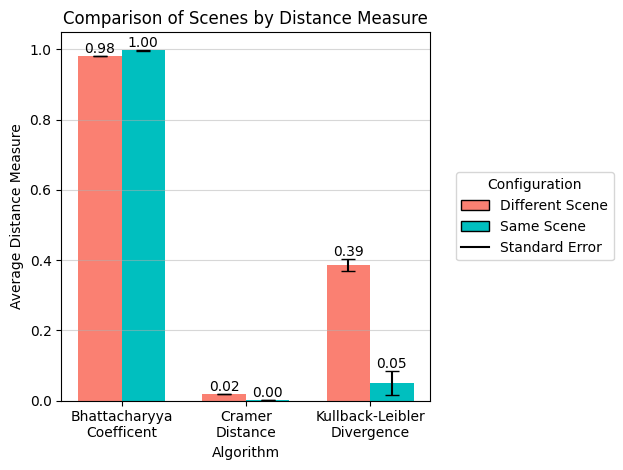

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

scenes = TrainSimilarityScores(f'2_fov/*/flex_train_similarity_scores/*.csv')
same, different = scenes.scene_metrics().values()

same_avg_kld, same_avg_cramer, same_avg_bhattacharyya = same['average'].values()
same_se_kld, same_se_cramer, same_se_bhattacharyya = same['standard_error'].values()
diff_avg_kld, diff_avg_cramer, diff_avg_bhattacharyya = different['average'].values()
diff_se_kld, diff_se_cramer, diff_se_bhattacharyya = different['standard_error'].values()

data = {
    'Algorithm': ['Bhattacharyya\nCoefficent', 'Cramer\nDistance', 'Kullback-Leibler\nDivergence'],
    'Different Scene': [diff_avg_bhattacharyya, diff_avg_cramer, diff_avg_kld],
    'Same Scene': [same_avg_bhattacharyya, same_avg_cramer, same_avg_kld],
    'Different Scene Error': [diff_se_bhattacharyya, diff_se_cramer, diff_se_kld],
    'Same Scene Error': [same_se_bhattacharyya, same_se_cramer, same_se_kld]
}
df = pd.DataFrame(data)

# Set up the plot
fig, ax = plt.subplots()
width = 0.35  # Width of the bars
x = np.arange(len(df['Algorithm']))

# Plot bars with error bars
bars_diff = ax.bar(x - width/2, df['Different Scene'], width, label='Different Scene', color='salmon', yerr=df['Different Scene Error'], capsize=5)
bars_same = ax.bar(x + width/2, df['Same Scene'], width, label='Same Scene', color='c', yerr=df['Same Scene Error'], capsize=5)
# bars3

# Set labels, title, and legend
ax.set_xlabel('Algorithm')
ax.set_ylabel('Average Distance Measure')
ax.set_xticks(x)
ax.set_xticklabels(df['Algorithm'])
ax.set_title('Comparison of Scenes by Distance Measure')

# Customize legend to have black border around legend patches
legend_handles = [
    FancyBboxPatch((0, 0), 1, 1, boxstyle="square,pad=0.1", edgecolor="black", facecolor='salmon'),
    FancyBboxPatch((0, 0), 1, 1, boxstyle="square,pad=0.1", edgecolor="black", facecolor='c'),
    Line2D([0], [0], color='black', lw=1.5, label='Standard Error')  # Horizontal line for standard error
]
ax.legend(legend_handles, ['Different Scene', 'Same Scene', 'Standard Error'], title='Configuration',
          bbox_to_anchor=(1.05, 0.5), loc='center left')
# ax.legend(title='Configuration', bbox_to_anchor=(1.05, 0.5), loc='center left')

# Adding labels on top of each bar
ax.bar_label(bars_diff, fmt='%.2f')
ax.bar_label(bars_same, fmt='%.2f')

# Add gridlines
plt.grid(True, axis='y', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()